# 04 · Style Transfer Demo

## 0 · Local Setup  *(run every session)*

In [12]:
from pathlib import Path
import sys, yaml

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists() and (PROJECT_ROOT.parent / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise FileNotFoundError(f'Cannot find project root from {Path.cwd()}')

sys.path.insert(0, str(PROJECT_ROOT))

missing = []
for pkg in ['pretty_midi', 'yaml']:
    try:
        __import__(pkg)
    except Exception:
        missing.append(pkg)
if missing:
    print(f'Missing packages: {missing}')
    print('Install with: pip install pretty_midi PyYAML')

with open(PROJECT_ROOT / 'configs' / 'base.yaml') as f:
    config = yaml.safe_load(f)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('Config loaded ✓')

PROJECT_ROOT = /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer
Config loaded ✓


## 1 · Imports & Load Model

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
from pathlib import Path
from torch.utils.data import DataLoader

from src.models.ec2vae       import EC2VAE
from src.data.dataset        import MusicDataset
from src.evaluation.visualize import (
    plot_piano_roll_comparison,
    plot_pitch_class_histograms,
    plot_rhythm_comparison,
    plot_latent_interpolation,
)
from src.evaluation.metrics  import (
    pitch_class_histogram_divergence,
    rhythmic_density, rhythmic_entropy, rhythmic_density_distance,
)

DATA_DIR = Path(PROJECT_ROOT) / 'data' / 'processed'
CKPT_BASE = Path(os.environ.get('MST_CHECKPOINT_BASE', str(PROJECT_ROOT))).expanduser().resolve()
CKPT_DIR = CKPT_BASE / 'checkpoints'
MIDI_DIR = Path(PROJECT_ROOT) / 'outputs' / 'midi'
FIG_DIR  = Path(PROJECT_ROOT) / 'outputs' / 'figures'
MIDI_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

GENRES  = ['jazz', 'pop']
SEQ_LEN = config['data']['seq_len']   # 32
FS      = config['data']['fs']         # 12 steps/beat

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Checkpoint dir: {CKPT_DIR}')

model = EC2VAE.from_config(config).to(device)
ckpt_path = CKPT_DIR / 'best_model.pt'
if not ckpt_path.exists():
    raise FileNotFoundError(f'Missing checkpoint: {ckpt_path}')
ckpt  = torch.load(str(ckpt_path), map_location=device)

load_info = model.load_state_dict(ckpt['model_state'], strict=False)
if load_info.missing_keys:
    print(f'Warning: missing keys in checkpoint: {load_info.missing_keys}')
if load_info.unexpected_keys:
    print(f'Warning: unexpected keys in checkpoint: {load_info.unexpected_keys}')

missing_set = set(load_info.missing_keys)
if {'decoder.rhythm_to_hidden.weight', 'decoder.rhythm_to_hidden.bias'}.issubset(missing_set):
    with torch.no_grad():
        model.decoder.rhythm_to_hidden.weight.zero_()
        model.decoder.rhythm_to_hidden.bias.zero_()
    print('Safety mode ON: decoder.rhythm_to_hidden was missing and has been zeroed.')

model.eval()
print(f'Loaded best_model.pt  epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

Device: cpu
Checkpoint dir: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/checkpoints
Safety mode ON: decoder.rhythm_to_hidden was missing and has been zeroed.
Loaded best_model.pt  epoch=64  val_loss=0.2459


## 2 · Load Test Set

In [ ]:
test_ds = MusicDataset(str(DATA_DIR), GENRES, split='test')
counts  = test_ds.genre_counts()

offsets = {}
cursor  = 0
for g in GENRES:
    offsets[g] = cursor
    cursor += counts[g]

print('Test set sizes per genre:')
for g in GENRES:
    print(f'  {g:<12}: {counts[g]:>5} segments  (offset={offsets[g]})')

def get_sample(genre: str, idx: int = 0):
    """Get a piano roll from the test set by genre name and within-genre index."""
    global_idx = offsets[genre] + idx
    x, _, _ = test_ds[global_idx]
    return x   

Test set sizes per genre:
  jazz        : 10516 segments  (offset=0)
  pop         : 10355 segments  (offset=10516)


---
## 3 · Style Transfer Demo


In [ ]:
DEMO_GROUPS = [
    {'name': 'group_jazz_to_pop_a', 'content_genre': 'jazz', 'content_idx': 3, 'style_genre': 'pop',  'style_idx': 7},
    {'name': 'group_pop_to_jazz_a', 'content_genre': 'pop',  'content_idx': 4, 'style_genre': 'jazz', 'style_idx': 2},
    {'name': 'group_jazz_to_pop_b', 'content_genre': 'jazz', 'content_idx': 8, 'style_genre': 'pop',  'style_idx': 1},
]

TRANSFER_TEMPERATURE = 1.0   
TRANSFER_THRESHOLD   = 0.7   
print('Demo groups:')
for i, g in enumerate(DEMO_GROUPS, 1):
    print(
        f"  [{i}] {g['name']}: {g['content_genre']}[{g['content_idx']}] -> "
        f"{g['style_genre']}[{g['style_idx']}]"
    )
print(f'Inference controls: temperature={TRANSFER_TEMPERATURE}, threshold={TRANSFER_THRESHOLD}')

Demo groups:
  [1] group_jazz_to_pop_a: jazz[3] -> pop[7]
  [2] group_pop_to_jazz_a: pop[4] -> jazz[2]
  [3] group_jazz_to_pop_b: jazz[8] -> pop[1]
Inference controls: temperature=1.0, threshold=0.7


In [ ]:
def run_single_transfer(content_genre: str, content_idx: int, style_genre: str, style_idx: int):
    x_content = get_sample(content_genre, content_idx)
    x_style   = get_sample(style_genre,   style_idx)

    x_c = x_content.unsqueeze(0).to(device)
    x_s = x_style.unsqueeze(0).to(device)

    with torch.no_grad():
        transferred_prob = model.transfer(
            x_c, x_s, temperature=TRANSFER_TEMPERATURE
        )

    transferred_bin = (transferred_prob.squeeze(0).cpu().numpy() > TRANSFER_THRESHOLD).astype(np.float32)
    x_c_np = x_content.numpy()
    x_s_np = x_style.numpy()

    pitch_kl = pitch_class_histogram_divergence(x_c_np, transferred_bin)
    rdd      = rhythmic_density_distance(transferred_bin, x_s_np)

    return {
        'content_genre': content_genre,
        'content_idx': content_idx,
        'style_genre': style_genre,
        'style_idx': style_idx,
        'x_c_np': x_c_np,
        'x_s_np': x_s_np,
        'transferred_bin': transferred_bin,
        'pitch_kl': float(pitch_kl),
        'rdd': float(rdd),
        'content_density': float(rhythmic_density(x_c_np)),
        'style_density': float(rhythmic_density(x_s_np)),
        'transferred_density': float(rhythmic_density(transferred_bin)),
    }


demo_results = []
print('Running transfer for all groups...')
print(f'Using temperature={TRANSFER_TEMPERATURE}, threshold={TRANSFER_THRESHOLD}')
for g in DEMO_GROUPS:
    result = run_single_transfer(
        content_genre=g['content_genre'],
        content_idx=g['content_idx'],
        style_genre=g['style_genre'],
        style_idx=g['style_idx'],
    )
    result['name'] = g['name']
    demo_results.append(result)

    print(f"\n[{g['name']}] {result['content_genre']}[{result['content_idx']}] -> {result['style_genre']}[{result['style_idx']}]")
    print(f"  Pitch KL divergence : {result['pitch_kl']:.4f}  (↓ melody preserved)")
    print(f"  Rhythm density dist : {result['rdd']:.4f}  (↓ rhythm adopted)")
    print(f"  Content density     : {result['content_density']:.3f}")
    print(f"  Style density       : {result['style_density']:.3f}")
    print(f"  Transferred density : {result['transferred_density']:.3f}")

x_c_np = demo_results[0]['x_c_np']
x_s_np = demo_results[0]['x_s_np']
transferred_bin = demo_results[0]['transferred_bin']
CONTENT_GENRE = demo_results[0]['content_genre']
STYLE_GENRE   = demo_results[0]['style_genre']

Running transfer for all groups...
Using temperature=1.0, threshold=0.7

[group_jazz_to_pop_a] jazz[3] -> pop[7]
  Pitch KL divergence : 0.6597  (↓ melody preserved)
  Rhythm density dist : 0.0000  (↓ rhythm adopted)
  Content density     : 0.031
  Style density       : 0.031
  Transferred density : 0.031

[group_pop_to_jazz_a] pop[4] -> jazz[2]
  Pitch KL divergence : 3.8155  (↓ melody preserved)
  Rhythm density dist : 0.0000  (↓ rhythm adopted)
  Content density     : 0.031
  Style density       : 0.031
  Transferred density : 0.031

[group_jazz_to_pop_b] jazz[8] -> pop[1]
  Pitch KL divergence : 0.3484  (↓ melody preserved)
  Rhythm density dist : 0.0000  (↓ rhythm adopted)
  Content density     : 0.062
  Style density       : 0.031
  Transferred density : 0.031


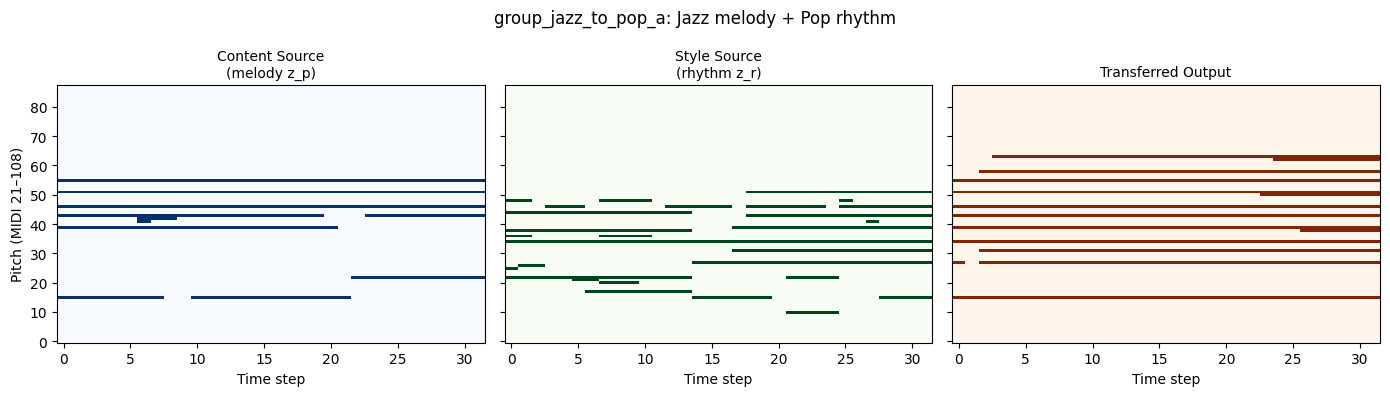

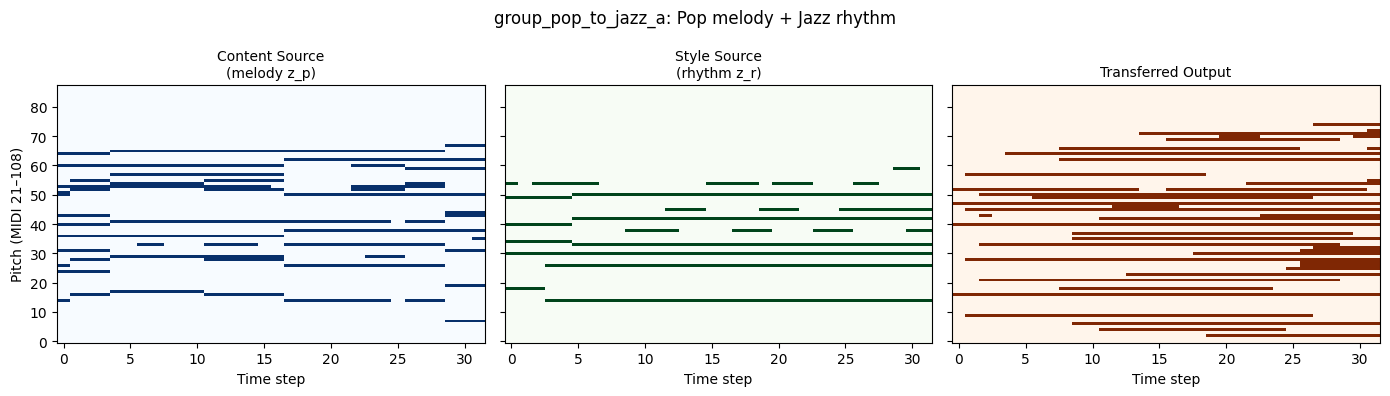

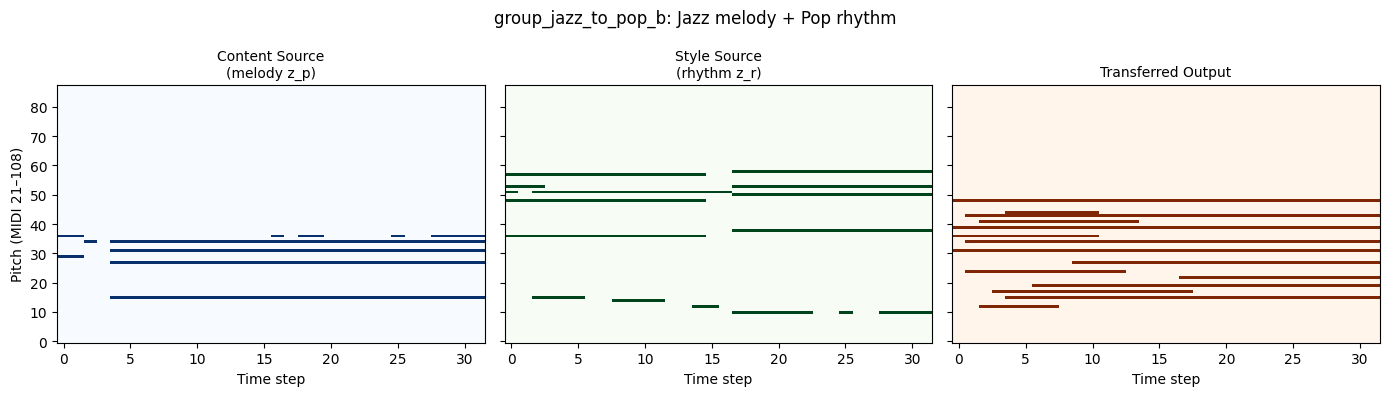

Saved per-group piano-roll plots to: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/figures/groups


In [6]:
GROUP_FIG_DIR = FIG_DIR / 'groups'
GROUP_FIG_DIR.mkdir(parents=True, exist_ok=True)

for result in demo_results:
    group_fig_dir = GROUP_FIG_DIR / result['name']
    group_fig_dir.mkdir(parents=True, exist_ok=True)

    plot_piano_roll_comparison(
        roll_content=result['x_c_np'],
        roll_style=result['x_s_np'],
        roll_transferred=result['transferred_bin'],
        title=(
            f"{result['name']}: "
            f"{result['content_genre'].capitalize()} melody + "
            f"{result['style_genre'].capitalize()} rhythm"
        ),
        save_path=str(group_fig_dir / 'pianoroll_comparison.png'),
    )

print(f'Saved per-group piano-roll plots to: {GROUP_FIG_DIR}')

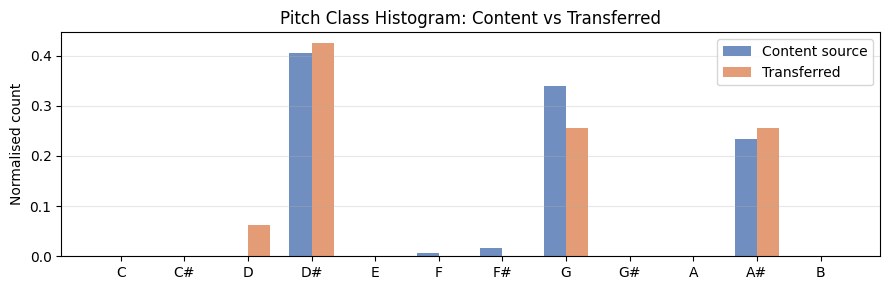

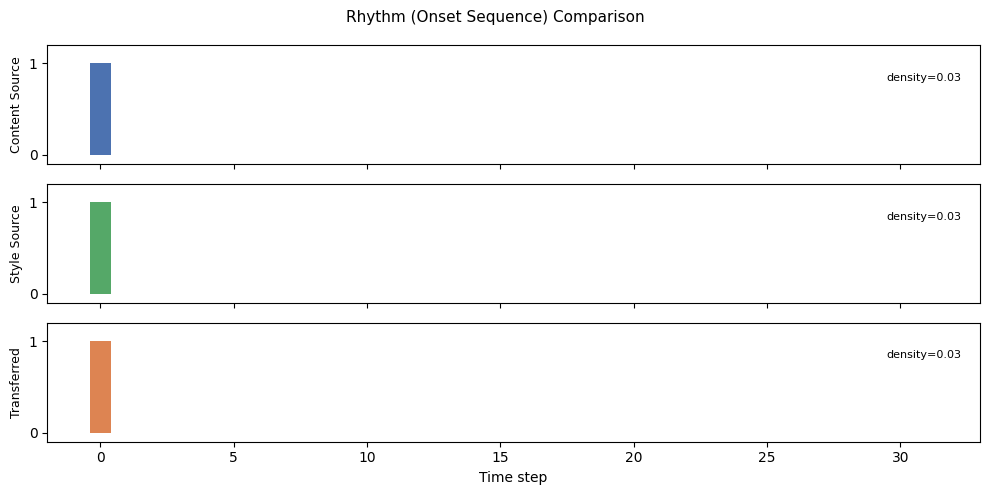

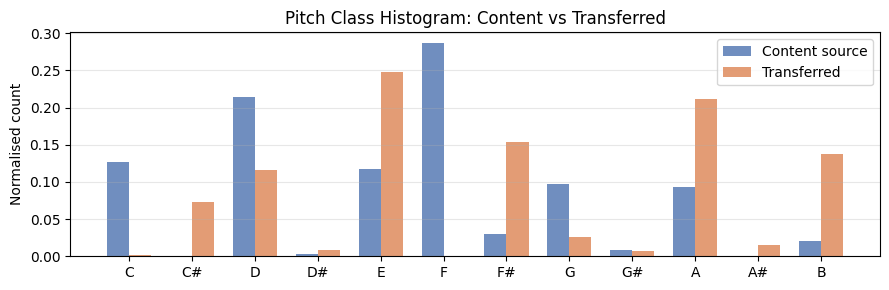

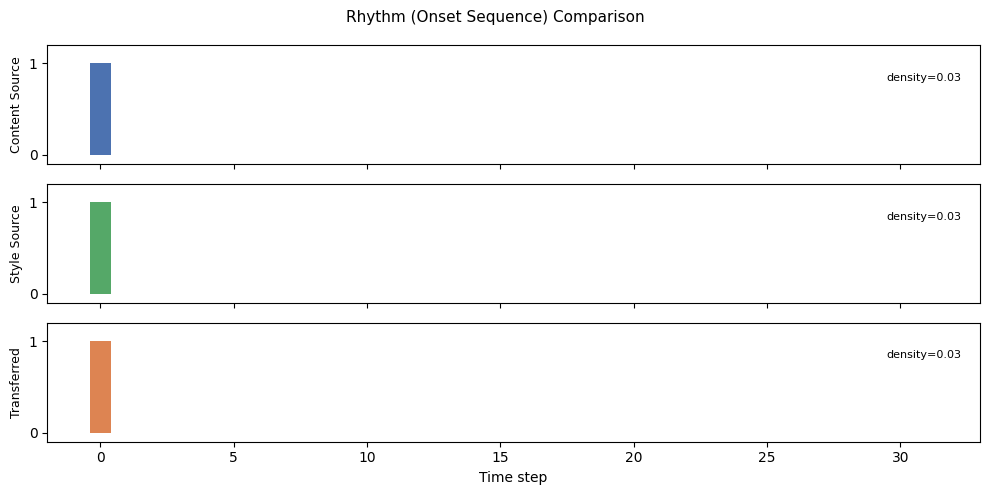

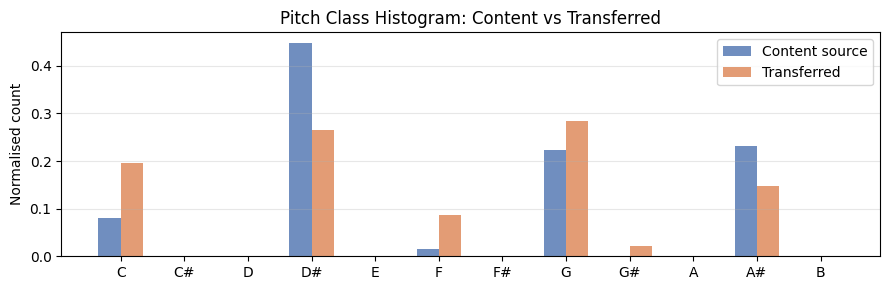

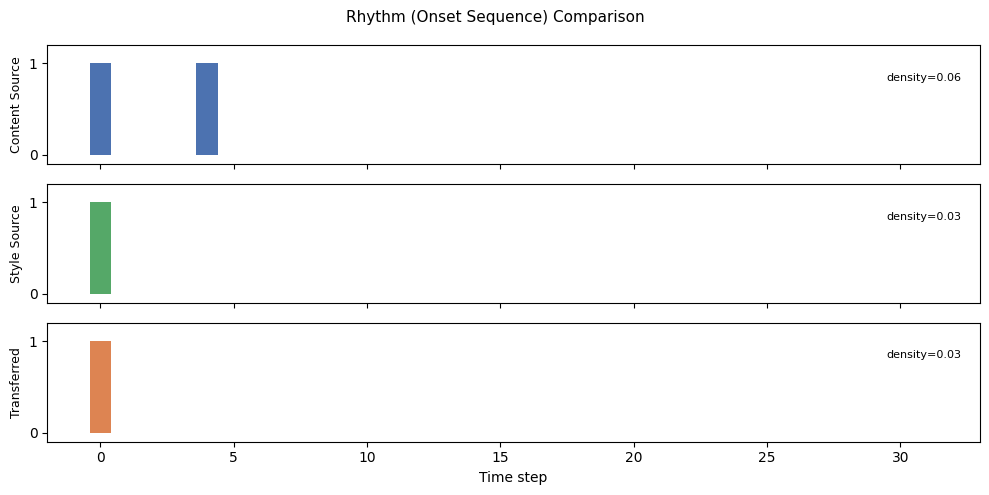

Saved per-group pitch/rhythm plots to: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/figures/groups


In [7]:
for result in demo_results:
    group_fig_dir = GROUP_FIG_DIR / result['name']
    group_fig_dir.mkdir(parents=True, exist_ok=True)

    plot_pitch_class_histograms(
        roll_content=result['x_c_np'],
        roll_transferred=result['transferred_bin'],
        save_path=str(group_fig_dir / 'pitch_histogram.png'),
    )

    plot_rhythm_comparison(
        roll_content=result['x_c_np'],
        roll_style=result['x_s_np'],
        roll_transferred=result['transferred_bin'],
        save_path=str(group_fig_dir / 'rhythm_comparison.png'),
    )

print(f'Saved per-group pitch/rhythm plots to: {GROUP_FIG_DIR}')

---
## 4 · Export Transferred Output as MIDI

In [ ]:
def piano_roll_to_midi(
    roll:      np.ndarray,
    fs:        int   = 12,
    pitch_low: int   = 21,
    tempo:     float = 120.0,
    velocity:  int   = 80,
) -> pretty_midi.PrettyMIDI:
    pm        = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=0)

    seconds_per_step = 60.0 / (tempo * fs)
    pitch_roll = roll[:, :88]

    for pitch_idx in range(88):
        midi_pitch = pitch_idx + pitch_low
        active     = False
        note_start = 0.0

        for t in range(pitch_roll.shape[0]):
            is_on = pitch_roll[t, pitch_idx] > 0.5
            if is_on and not active:
                note_start = t * seconds_per_step
                active     = True
            elif not is_on and active:
                note_end = t * seconds_per_step
                instrument.notes.append(
                    pretty_midi.Note(velocity, midi_pitch, note_start, note_end)
                )
                active = False

        if active:
            instrument.notes.append(
                pretty_midi.Note(
                    velocity, midi_pitch, note_start,
                    pitch_roll.shape[0] * seconds_per_step
                )
            )

    pm.instruments.append(instrument)
    return pm


pitch_low = config['data']['pitch_low']
GROUP_MIDI_DIR = MIDI_DIR / 'groups'
GROUP_MIDI_DIR.mkdir(parents=True, exist_ok=True)

for result in demo_results:
    group_midi_dir = GROUP_MIDI_DIR / result['name']
    group_midi_dir.mkdir(parents=True, exist_ok=True)

    midi_items = [
        ('content.mid', result['x_c_np']),
        ('style.mid', result['x_s_np']),
        ('transferred.mid', result['transferred_bin']),
    ]

    for fname, roll in midi_items:
        pm   = piano_roll_to_midi(roll, fs=FS, pitch_low=pitch_low)
        path = group_midi_dir / fname
        pm.write(str(path))
        print(f"[{result['name']}] Saved: {path}")

print(f'\nAll grouped MIDI files saved to: {GROUP_MIDI_DIR}')

[group_jazz_to_pop_a] Saved: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups/group_jazz_to_pop_a/content.mid
[group_jazz_to_pop_a] Saved: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups/group_jazz_to_pop_a/style.mid
[group_jazz_to_pop_a] Saved: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups/group_jazz_to_pop_a/transferred.mid
[group_pop_to_jazz_a] Saved: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups/group_pop_to_jazz_a/content.mid
[group_pop_to_jazz_a] Saved: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups/group_pop_to_jazz_a/style.mid
[group_pop_to_jazz_a] Saved: /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups/group_pop_to_jazz_a/transferred.mid
[group_jazz_to_pop_b] Saved: /Users/chunjuanjuan/Documents/DEV/pro

---
## 5 · z_r Latent Interpolation

In [ ]:
INTERP_CONTENT_GENRE = 'jazz'
INTERP_CONTENT_IDX   = 3
INTERP_STYLE_A_GENRE = 'jazz'
INTERP_STYLE_A_IDX   = 0
INTERP_STYLE_B_GENRE = 'pop'
INTERP_STYLE_B_IDX   = 0
INTERP_STEPS         = 8

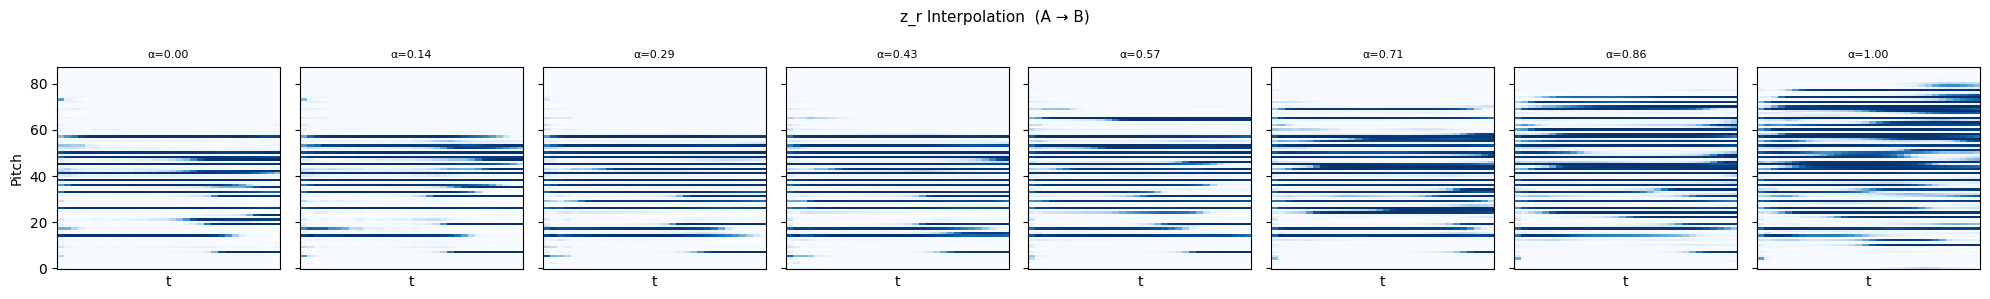

In [11]:
x_interp_content = get_sample(INTERP_CONTENT_GENRE, INTERP_CONTENT_IDX).unsqueeze(0).to(device)
x_interp_a       = get_sample(INTERP_STYLE_A_GENRE, INTERP_STYLE_A_IDX).unsqueeze(0).to(device)
x_interp_b       = get_sample(INTERP_STYLE_B_GENRE, INTERP_STYLE_B_IDX).unsqueeze(0).to(device)

plot_latent_interpolation(
    model=model,
    x_a=x_interp_a,
    x_b=x_interp_b,
    device=device,
    n_steps=INTERP_STEPS,
    save_path=str(FIG_DIR / f'demo_interpolation_{INTERP_STYLE_A_GENRE}_to_{INTERP_STYLE_B_GENRE}.png'),
)

---
## 6 · Batch Transfer Gallery

Run all 6 cross-genre transfer pairs and show a summary grid.

Batch Gallery sample switch:
  jazz[11] -> pop[16] | poly: c=4.59, s=8.09, t=16.81
  pop[9] -> jazz[14] | poly: c=7.47, s=2.41, t=19.03


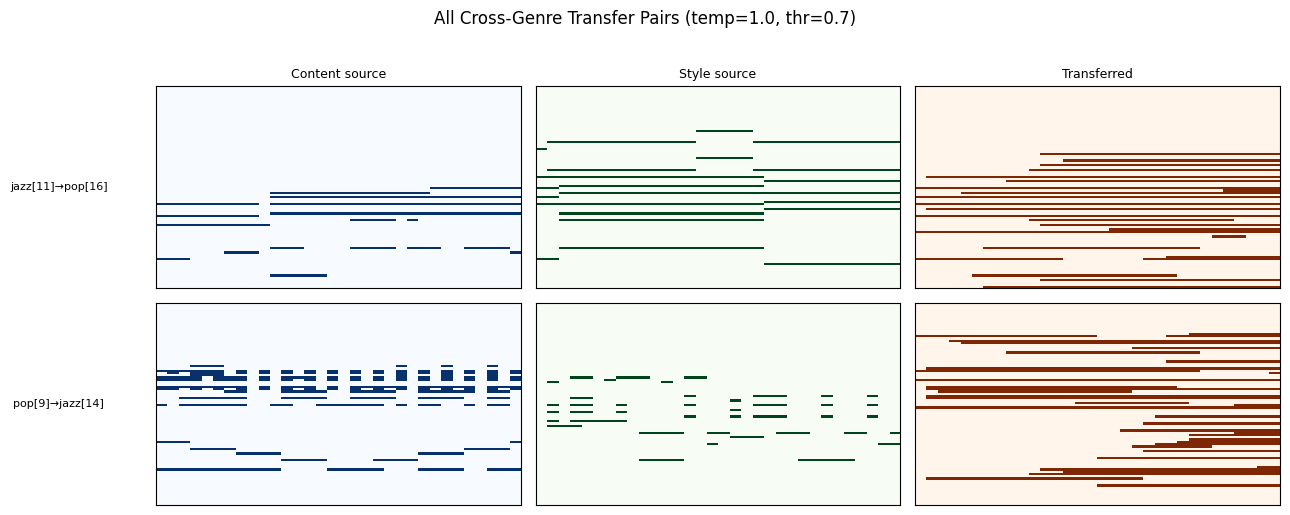

In [16]:
pairs = [
    ('jazz', 'pop', 11, 16),
    ('pop',  'jazz', 9, 14),
]

fig, axes = plt.subplots(len(pairs), 3, figsize=(13, 2.5 * len(pairs)))
if len(pairs) == 1:
    axes = np.expand_dims(axes, axis=0)

col_labels = ['Content source', 'Style source', 'Transferred']
cmaps = ['Blues', 'Greens', 'Oranges']

print('Batch Gallery sample switch:')
for row, (content_g, style_g, c_idx, s_idx) in enumerate(pairs):
    # Clamp indices to valid range for safety when test split size changes.
    c_idx = min(c_idx, counts[content_g] - 1)
    s_idx = min(s_idx, counts[style_g] - 1)

    xc = get_sample(content_g, c_idx).unsqueeze(0).to(device)
    xs = get_sample(style_g, s_idx).unsqueeze(0).to(device)

    with torch.no_grad():
        tf = model.transfer(
            xc, xs, temperature=TRANSFER_TEMPERATURE
        ).squeeze(0).cpu().numpy()
    tf_bin = (tf > TRANSFER_THRESHOLD).astype(np.float32)

    c_poly = float(xc[:, :, :88].sum().item() / SEQ_LEN)
    s_poly = float(xs[:, :, :88].sum().item() / SEQ_LEN)
    t_poly = float(tf_bin[:, :88].sum() / SEQ_LEN)
    print(f"  {content_g}[{c_idx}] -> {style_g}[{s_idx}] | poly: c={c_poly:.2f}, s={s_poly:.2f}, t={t_poly:.2f}")

    rolls = [xc.squeeze(0).cpu().numpy(), xs.squeeze(0).cpu().numpy(), tf_bin]

    for col, (ax, roll, cmap) in enumerate(zip(axes[row], rolls, cmaps)):
        ax.imshow(roll[:, :88].T, aspect='auto', origin='lower',
                  cmap=cmap, interpolation='nearest', vmin=0, vmax=1)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=9)
        if col == 0:
            ax.set_ylabel(
                f'{content_g}[{c_idx}]→{style_g}[{s_idx}]',
                fontsize=8, rotation=0, labelpad=70, va='center'
            )
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle(
    f'All Cross-Genre Transfer Pairs (temp={TRANSFER_TEMPERATURE}, thr={TRANSFER_THRESHOLD})',
    fontsize=12,
    y=1.02,
 )
plt.tight_layout()
plt.savefig(str(FIG_DIR / 'demo_batch_gallery.png'), bbox_inches='tight', dpi=120)
plt.show()

---
## 7 · Summary

In [13]:
print('=' * 60)
print('Demo Complete')
print('=' * 60)

group_midi_dir = MIDI_DIR / 'groups'
group_fig_dir  = FIG_DIR / 'groups'

print('Grouped outputs:')
if group_midi_dir.exists():
    for p in sorted(group_midi_dir.glob('*')):
        if p.is_dir():
            midi_count = len(list(p.glob('*.mid')))
            print(f'  MIDI  group {p.name:<24} : {midi_count} files')

if group_fig_dir.exists():
    for p in sorted(group_fig_dir.glob('*')):
        if p.is_dir():
            fig_count = len(list(p.glob('*.png')))
            print(f'  Figure group {p.name:<22} : {fig_count} files')

print('\nMain directories:')
print(f'  MIDI   -> {group_midi_dir}')
print(f'  Figure -> {group_fig_dir}')
print('=' * 60)

Demo Complete
Grouped outputs:
  MIDI  group group_jazz_to_pop_a      : 3 files
  MIDI  group group_jazz_to_pop_b      : 3 files
  MIDI  group group_pop_to_jazz_a      : 3 files
  Figure group group_jazz_to_pop_a    : 3 files
  Figure group group_jazz_to_pop_b    : 3 files
  Figure group group_pop_to_jazz_a    : 3 files

Main directories:
  MIDI   -> /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/midi/groups
  Figure -> /Users/chunjuanjuan/Documents/DEV/projects/gnn_final/music-style-transfer/outputs/figures/groups
